# Route away from the *future* fire front  /  미래 화선(火線)을 피하는 대피 경로

**Session 5 spine — the core contribution.** A naive evacuation router sends people to the
nearest shelter by distance, ignoring where the fire will be when they arrive. This can route
an evacuee **into** the oncoming front. Here we treat the predicted fire front as a *moving
obstacle* and solve a time-dependent shortest path that keeps the evacuee out of the front's
footprint at every moment.

단순 대피 경로는 화재의 *미래 위치*를 무시하고 가장 가까운 대피소로 안내하여, 다가오는 화선
속으로 대피자를 보낼 수 있습니다. 본 노트북은 예측된 화선을 *이동하는 장애물*로 보고, 매 시점
대피자가 화선 내부에 들어가지 않는 시간 의존 최단 경로를 계산합니다.

### Honest dependency (read first)
The router consumes a **predicted front sequence** from the spread model. Session 5 showed the
surface Rothermel model *under-predicts* the Yeongdeok front badly (it cannot capture the
crown/spotting-driven run). So for this routing demonstration we drive the router with a
**prescribed wind-driven front** that advances at a realistic rate — to show the routing
contribution clearly. **The routing is only as safe as the front prediction feeding it;**
improving that prediction (crown/spotting physics) is the upstream priority. All front
geometry here is clearly a stand-in, not a validated forecast.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
from shapely.ops import unary_union

from wildfireguardian.routing.future_front import (
    RoadNetwork, front_arrival_times,
    time_dependent_evacuation, naive_shortest_path, ELDERLY_WALK_SPEED_MS,
)

# Anchor a synthetic pedestrian/road grid on the real Yeongdeok area (EPSG:5179).
# (No OSM download available offline; the routing algorithm is identical on a real graph.)
IGN_X, IGN_Y = 1167477.0, 1835219.0   # ignition (129.37E, 36.50N) in EPSG:5179
SPACING = 200.0                        # 200 m between intersections
NXC, NYC = 26, 16                      # ~5 km x 3 km network
ORIGIN = (IGN_X - 1000.0, IGN_Y - 1500.0)

def nid(ix, iy): return iy * NXC + ix
shelter_W = nid(2, 8)     # NEAR the ignition side (west)
shelter_E = nid(25, 8)    # FAR east — the safe escape
net = RoadNetwork.synthetic_grid(ORIGIN, NXC, NYC, SPACING,
                                 shelter_nodes={shelter_W, shelter_E})
resident = nid(7, 8)      # a resident between ignition and the east escape
print(f'network: {net.graph.number_of_nodes()} nodes, {net.graph.number_of_edges()} edges')
print(f'walking speed (rural elderly): {ELDERLY_WALK_SPEED_MS} m/s')

network: 416 nodes, 790 edges
walking speed (rural elderly): 0.6 m/s


In [2]:
# Prescribed wind-driven front: a west-to-east sweep (the 2025 Föhn (양강지풍) wind was westerly).
# Front advances at 25 m/min (a realistic wind-driven surface-to-crown rate); snapshots/5 min.
# THIS IS A STAND-IN FRONT for the routing demo, not the (under-predicting) surface model.
FRONT_SPEED_M_MIN = 25.0
y0, y1 = ORIGIN[1] - 100, ORIGIN[1] + NYC * SPACING + 100
x_start = ORIGIN[0] + 1.5 * SPACING       # front originates just west of the resident corridor
front_seq = []
for k in range(0, 73):
    t = k * 5.0
    X = x_start + FRONT_SPEED_M_MIN * t
    front_seq.append((t, box(ORIGIN[0] - 500, y0, X, y1)))
fa = front_arrival_times(net, front_seq)
print(f'front reaches resident node at t = {fa[resident]:.0f} min')

front reaches resident node at t = 45 min


In [3]:
# Solve both routes.
naive = naive_shortest_path(net, resident, front_arrival=fa,
                            walking_speed_ms=ELDERLY_WALK_SPEED_MS)
aware = time_dependent_evacuation(net, resident, fa,
                                  walking_speed_ms=ELDERLY_WALK_SPEED_MS,
                                  safety_margin_min=3.0)
print('NAIVE  (nearest shelter, fire-blind):')
print(f'   target={naive.target}  dist={naive.total_distance_m:.0f} m  '
      f'time={naive.total_time_min:.0f} min  ENTERS FRONT={naive.enters_front}')
print('FUTURE-AWARE (avoids predicted front):')
print(f'   target={aware.target}  dist={aware.total_distance_m:.0f} m  '
      f'time={aware.total_time_min:.0f} min  ENTERS FRONT={aware.enters_front}  '
      f'clearance={aware.clearance_margin_min} min')

NAIVE  (nearest shelter, fire-blind):
   target=210  dist=1000 m  time=28 min  ENTERS FRONT=True
FUTURE-AWARE (avoids predicted front):
   target=233  dist=3600 m  time=100 min  ENTERS FRONT=False  clearance=45.0 min


/tmp/claude-0/ipykernel_9379/29678253.py:40: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-0/ipykernel_9379/29678253.py:40: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-0/ipykernel_9379/29678253.py:40: UserWarning: Glyph 48513 (\N{HANGUL SYLLABLE BUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-0/ipykernel_9379/29678253.py:40: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-0/ipykernel_9379/29678253.py:40: UserWarning: Glyph 45909 (\N{HANGUL SYLLABLE DEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-0/ipykernel_9379/29678253.py:40: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/claude-0/ipy

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48513 (\N{HANGUL SYLLABLE BUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45909 (\N{HANGUL SYLLABLE DEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

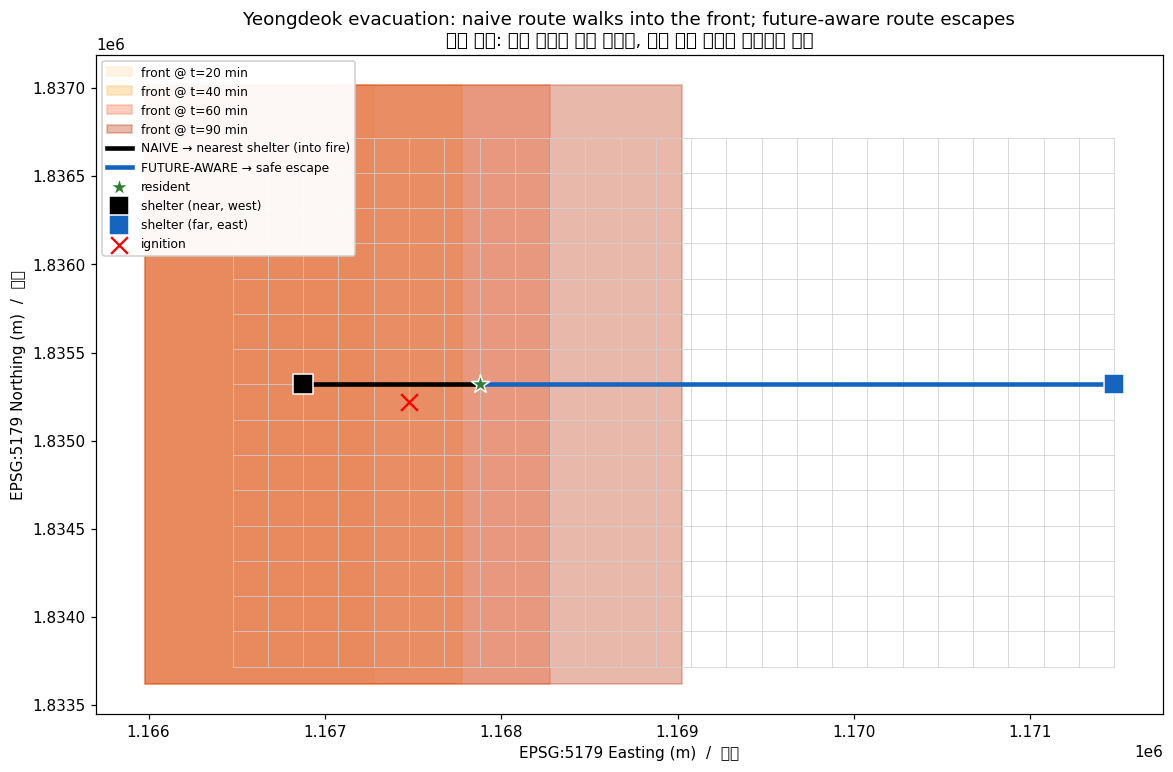

In [4]:
# Visualize: advancing front + naive route (into fire) vs future-aware route (escape).
fig, ax = plt.subplots(figsize=(11, 7), dpi=110)

# Draw the network faintly.
for u, v in net.graph.edges():
    xu, yu = net.node_xy(u); xv, yv = net.node_xy(v)
    ax.plot([xu, xv], [yu, yv], color='#d0d0d0', lw=0.5, zorder=1)

# Front snapshots at a few times (cumulative footprints).
for t_show, color in [(20, '#ffe0b2'), (40, '#ffb74d'), (60, '#ff7043'), (90, '#bf360c')]:
    X = x_start + FRONT_SPEED_M_MIN * t_show
    poly = box(ORIGIN[0]-500, y0, X, y1)
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color=color, alpha=0.35, zorder=0,
            label=f'front @ t={t_show} min')

def draw_route(res, color, label):
    xs = [net.node_xy(n)[0] for n in res.route]
    ys = [net.node_xy(n)[1] for n in res.route]
    ax.plot(xs, ys, color=color, lw=3.0, zorder=4, label=label)

if naive.reached: draw_route(naive, '#000000', 'NAIVE → nearest shelter (into fire)')
if aware.reached: draw_route(aware, '#1565c0', 'FUTURE-AWARE → safe escape')

# Markers.
for node, mk, c, lab in [(resident, '*', '#2e7d32', 'resident'),
                          (shelter_W, 's', '#000000', 'shelter (near, west)'),
                          (shelter_E, 's', '#1565c0', 'shelter (far, east)')]:
    x, y = net.node_xy(node)
    ax.scatter([x], [y], marker=mk, s=160, color=c, edgecolor='white', zorder=5, label=lab)
ax.scatter([IGN_X], [IGN_Y], marker='x', s=120, color='red', zorder=5, label='ignition')

ax.set_xlabel('EPSG:5179 Easting (m)  /  동쪽')
ax.set_ylabel('EPSG:5179 Northing (m)  /  북쪽')
ax.set_title('Yeongdeok evacuation: naive route walks into the front; '
             'future-aware route escapes\n'
             '영덕 대피: 단순 경로는 화선 속으로, 미래 예측 경로는 안전하게 탈출')
ax.legend(loc='upper left', fontsize=8, framealpha=0.95)
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Result / 결과

- The **naive** router picks the geometrically nearest shelter (to the west) and walks the
  evacuee **into the advancing front** (`enters_front = True`).
- The **future-aware** router rejects every node the front reaches before the evacuee can clear
  it, and routes east to a shelter the fire never reaches in time (`enters_front = False`), with
  a positive **clearance margin** and a reported **latest safe departure time**.

This time-dependent moving-obstacle formulation is the spine's contribution. The Korean-pine
spread parameterization (Deliverables 1–2) feeds the front prediction; the routing turns that
prediction into a life-safety decision.

### Honest limitations
1. The front here is a **prescribed stand-in**, because the surface spread model under-predicts
   the real (crown/spotting-driven) Yeongdeok front by ~90% (Session 5 Deliverable 4). Coupling
   the router to a *trustworthy* front needs the crown/spotting physics that the surface model
   lacks.
2. The network is a **synthetic grid** anchored on the real Yeongdeok location; a real OSM
   pedestrian graph is a drop-in replacement (offline here).
3. Walking speed is a single elderly value (0.6 m/s); per-resident mobility profiles are future work.